In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

In [50]:

# nominal CoSMO type
n_strains = 2
n_resources = 3

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[0,1] = 2
c[1,2] = 2

l = np.zeros((n_strains,n_resources))
degree = 0
l[0,0] = 1*degree
l[1,0] = 1*degree

#nutrient "quality"
w = np.ones(n_resources)

#chemostat feeding
k = np.zeros(n_resources)
k[0] = 1

#chemostat dilution rate
r = np.ones(n_resources)*0.2
#r = np.array([1,0.2,0.2])

#death rate
m = np.ones(n_strains)*0.9

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,2,0] = 1
CF_array[1,1,0] = 1

print(c)

print(CF_array)

ratios = np.array([0.3,0.7])

D = np.array([0.01,0.01]) #diffusion constant for cells

H = np.array([20,1,1]) #diffusion constants for resources


[[2. 2. 0.]
 [2. 0. 2.]]
[[[0. 0. 0.]
  [0. 0. 0.]
  [1. 0. 0.]]

 [[0. 0. 0.]
  [1. 0. 0.]
  [0. 0. 0.]]]


In [51]:
"""
# nominal CoSMO circle, separate glucoses
n_strains = 3
n_resources = 6

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,1] = 2
c[2,2] = 2
c[0,3] = 2
c[1,4] = 2
c[2,5] = 2

l = np.array([1,1,1,0,0,0])

w = np.array([1,1,1,1,1,1])

k = np.array([1,1,1,0,0,0])

r = np.array([1,1,1,0.2,0.2,0.2])

m = np.array([0.9,0.9,0.9])

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[4,0] = 1
CF_array[5,1] = 1
CF_array[3,2] = 1

print(c)
print(CF_array)

ratios = np.array([0.3,0.5,0.2])

D = np.array([0.01,0.01,0.01]) #diffusion constant for cells

H = np.array([100,100,100,1,1,1]) #diffusion constants for resources
"""

'\n# nominal CoSMO circle, separate glucoses\nn_strains = 3\nn_resources = 6\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,1] = 2\nc[2,2] = 2\nc[0,3] = 2\nc[1,4] = 2\nc[2,5] = 2\n\nl = np.array([1,1,1,0,0,0])\n\nw = np.array([1,1,1,1,1,1])\n\nk = np.array([1,1,1,0,0,0])\n\nr = np.array([1,1,1,0.2,0.2,0.2])\n\nm = np.array([0.9,0.9,0.9])\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[4,0] = 1\nCF_array[5,1] = 1\nCF_array[3,2] = 1\n\nprint(c)\nprint(CF_array)\n\nratios = np.array([0.3,0.5,0.2])\n\nD = np.array([0.01,0.01,0.01]) #diffusion constant for cells\n\nH = np.array([100,100,100,1,1,1]) #diffusion constants for resources\n'

In [52]:
"""

# nominal linear chain
n_strains = 2
n_resources = 4

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,1] = 0
c[0,2] = 0
c[1,3] = 2

l = np.array([0.5,0,0,0])

w = np.array([1,1,1,1])

k = np.array([1,1,0,0])

r = np.array([1,1,0.2,0.2])

m = np.array([0.6,0.4])

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[3,0] = 1
#CF_array[2,1] = 1

print(c)
print(CF_array)

"""

'\n\n# nominal linear chain\nn_strains = 2\nn_resources = 4\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,1] = 0\nc[0,2] = 0\nc[1,3] = 2\n\nl = np.array([0.5,0,0,0])\n\nw = np.array([1,1,1,1])\n\nk = np.array([1,1,0,0])\n\nr = np.array([1,1,0.2,0.2])\n\nm = np.array([0.6,0.4])\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[3,0] = 1\n#CF_array[2,1] = 1\n\nprint(c)\nprint(CF_array)\n\n'

In [53]:
def get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final):
    
    steady_state = False
    
    attempts = 0
    
    while not steady_state:
        
        if attempts > 0:
            
            t_final = t_final*2
            print('No steady state found on attempt %s'%attempts, ' running for longer')
            
            
        epsilon = 1e-4
        t_min = 10
        
        
        nsteps = int(t_final/dt)

        time = np.zeros(nsteps+1)

        N = np.zeros((n_strains,nsteps+1))
        N[:,0] = N_0*ratios

        R = np.zeros((n_resources,nsteps+1)) + R_0
        #R[0,0] = R_0

        for tt in range(nsteps):


            #I am too lazy to figure out matricies, although I'm sure that's easy
            dN = np.zeros(n_strains)
            for ii in range(n_strains):
                dN[ii] = -1/tau*N[ii,tt]*m[ii]
                for aa in range(n_resources):
                    dN[ii] += 1/tau*N[ii,tt]*(1-l[ii,aa])*w[aa]*c[ii,aa]*R[aa,tt]

            dR = np.zeros(n_resources)
            for aa in range(n_resources):
                dR[aa] = k[aa] - r[aa]*R[aa,tt]

                for ii in range(n_strains):
                    dR[aa] += -N[ii,tt]*c[ii,aa]*R[aa,tt]

                    for bb in range(n_resources):
                        dR[aa] += N[ii,tt]*CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]*R[bb,tt]


            N[:,tt+1] = N[:,tt] + dN*dt
            R[:,tt+1] = R[:,tt] + dR*dt
            time[tt+1] = time[tt]+dt


            if time[tt+1] > t_min and np.sum(dN) < epsilon and not steady_state:
                steady_state = True
                Nss = N[:,tt+1]
                Rss = R[:,tt+1]
                Tss = time[tt+1]
                #break
        
        attempts += 1
        
        if attempts > 5:
            break
    
    return N[:,:tt+1],R[:,:tt+1],time[:tt+1],Nss,Rss,Tss

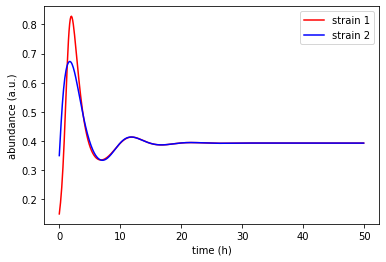

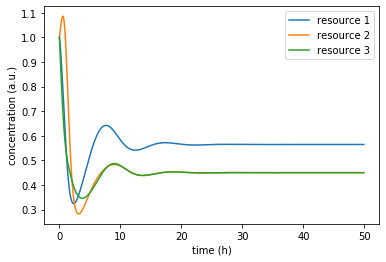

In [54]:
stride = 100
for nn in range(n_strains):
    if nn==0:
        col = 'r'
    else:
        col = 'b'
    plt.plot(time[::stride],N[nn,::stride],label='strain %s'%int(nn+1),c = col)
    #plt.axhline(y=Nss[nn])
plt.legend()
#plt.axvline(x=Tss)
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(n_resources):
    plt.plot(time[::stride],R[rr,::stride],label='resource %s'%int(rr+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()


In [55]:
def get_A_F(n_strains, n_resources, tau,l,w,c,CF_array):
    
    # make A
    A = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            A[aa,ii] = tau*(1-l[ii,aa])*w[aa]*c[ii,aa]
            
    #make F
    F = np.zeros((n_strains,n_resources,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            for bb in range(n_resources):
                F[ii,aa,bb] = CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]
                
    return A,F

In [56]:
def calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q):
    
    T = np.zeros((n_strains,n_strains))
    
    for ii in range(n_strains):
        #this matrix is diagonal, so we only need to loop through once
        T[ii,ii] = -D[ii]*q**2 - B[ii]
        
        for bb in range(n_resources):
             T[ii,ii] += Rss[bb]*A[bb,ii]
    
    return T

def calc_U(n_strains,n_resources,Nss,A):
    
    U = np.zeros((n_strains,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            U[ii,aa] = A[aa,ii]*Nss[ii]
            
    return U

def calc_W(n_strains,n_resources,Nss,F,H,r,c,q):
    
    W = np.zeros((n_resources,n_resources))
    for aa in range(n_resources):
        for bb in range(n_resources):
            if aa==bb:
                #print('H = ',np.size(H))
                #print('r = ',np.size(r))
                W[aa,bb] = -(q**2*H[aa] + r[aa])
            else:
                W[aa,bb]
        
            for jj in range(n_strains):

                W[aa,bb] += Nss[jj]*F[jj,aa,bb]
                
                if aa==bb:
                    
                    W[aa,bb] += -Nss[jj]*c[jj,aa]
    
    return W

def calc_V(n_strains,n_resources,Rss,F,c):
    
    V = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            V[aa,ii] = -c[ii,aa]*Rss[aa]
            
            for bb in range(n_resources):
                V[aa,ii] += F[ii,aa,bb]*Rss[bb]
    return V

def build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q):
    
    M = np.zeros((int(n_strains+n_resources),int(n_strains+n_resources)))
    
    T = calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q)
    W = calc_W(n_strains,n_resources,Nss,F,H,r,c,q)
    
    M[0:n_strains,0:n_strains] = T
    M[0:n_strains,n_strains:] = U
    M[n_strains:,0:n_strains] = V
    M[n_strains:,n_strains:] = W
    
    return M

"""
#lets actually calculate some stuff!
#first, the steady state for our parameter set
N_0 = 0.02
R_0 = 1
dt = 0.01
t_final = 1000
Nss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)
"""



'\n#lets actually calculate some stuff!\n#first, the steady state for our parameter set\nN_0 = 0.02\nR_0 = 1\ndt = 0.01\nt_final = 1000\nNss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)\n'

In [61]:
#troubleshooting for the steady state function
num = 6
degree = np.linspace(0,1,num)

npts = 1000
maxes = np.zeros((num,npts))

for ii in range(num):

    l = np.zeros((n_strains,n_resources))
    l[0,0] = 1*degree[ii]
    l[1,0] = 1*degree[ii]
    
    N_0 = 0.5
    R_0 = 1
    dt = 0.001
    t_final = 50

    N,R,time,Nss,Rss,Tss = get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final)

    A,F = get_A_F(n_strains, n_resources, tau,l,w,c,CF_array)

    U = calc_U(n_strains,n_resources,Nss,A)
    V = calc_V(n_strains,n_resources,Rss,F,c)

    #now its time to calculate some lambdas as a function of q

    qs = np.linspace(0,10,npts)

    #qs = 1/lengths

    lambdas = np.zeros((int(n_strains+n_resources),npts))

    for nn in range(npts):

        q = qs[nn]

        M = build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q)

        vals,vecs = la.eig(M)

        lambdas[:,nn] = vals
    
    maxes[ii,:] = np.max(lambdas,axis = 0)

/Users/stevenredford/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:42: ComplexWarning: Casting complex values to real discards the imaginary part


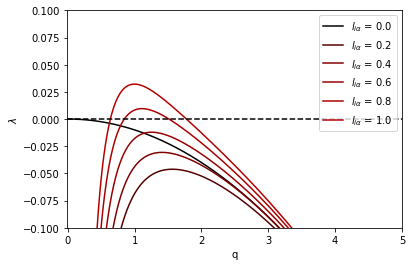

In [63]:
for nn in range(num):
    #col = [nn/(5+nn),0,1-nn/(5+nn)]
    col = [nn/(2+nn),0,0]
    lbl = r'$ l_{i \alpha}$'+' = %s'%np.round(degree[nn],1)
    plt.plot(qs,maxes[nn,:],c = col,label = lbl)
plt.xlabel('q')
plt.ylabel('$\lambda$')
plt.legend()
plt.ylim(-0.1,0.1)
plt.axhline(y=0,c='k',ls='--')
plt.xlim(-0.01,5)
plt.show()